# ¿Sirve este dataset para entrenar un modelo de precio?

Diagnóstico mediante clustering, antes de escribir una línea de modelo.

## El enfoque: por qué el clustering responde esta pregunta

Queremos construir un modelo hedónico que estime el **precio** de una propiedad a partir de sus
**atributos**. Antes de intentarlo conviene saber si esa relación existe en los datos, porque si no
existe ningún modelo la va a encontrar.

La idea central del diagnóstico es esta:

> **Agrupamos las propiedades usando solo sus atributos, sin dejar que el algoritmo vea el precio.
> Después miramos si los grupos resultantes tienen precios distintos.**

Si al agrupar por superficie, dormitorios y ubicación resulta que unos grupos valen 2.000 UF y otros
8.000, entonces los atributos contienen información sobre el precio y un modelo supervisado puede
aprovecharla. Si en cambio todos los grupos tienen el mismo precio mediano, los atributos no
discriminan y el dataset no sirve para lo que queremos.

Es una prueba **no paramétrica**: no asume ninguna forma funcional. No dice cuál será el error del
modelo final —un modelo supervisado siempre lo hará mejor que agrupar a ciegas— sino que establece
una **cota inferior de la señal disponible**.

⚠️ El precio queda **fuera** de la matriz de clustering. Incluirlo haría la prueba circular: los
grupos tendrían precios distintos por construcción y no habríamos aprendido nada.

### Las variables que vamos a usar

| Variable | Qué es | Por qué debería importar |
|---|---|---|
| `m2_util` | Superficie interior habitable, en m² | Es el determinante principal del precio en cualquier mercado |
| `m2_total` | Útil más terrazas y balcones | Distingue un depto con terraza de uno sin ella |
| `dormitorios` | Número de dormitorios (0 = monoambiente) | Define el tipo de hogar al que apunta |
| `banos` | Número de baños | Proxy del estándar de la propiedad |
| `estacionamientos` | Estacionamientos incluidos | En Santiago suma valor de forma independiente |
| `bodegas` | Bodegas incluidas | Lo mismo, con menor peso |
| `antiguedad` | Años desde la construcción (2026 − año) | Un edificio nuevo se transa distinto que uno de 1970 |
| `gastos_comunes_clp` | Gasto común mensual | Proxy del nivel del edificio: conserjería, amenidades |
| `lat`, `lon` | Coordenadas | La ubicación es el otro gran determinante junto con la superficie |

**Fuera de la matriz, a propósito:** `precio_uf` y `precio_clp` porque son el objetivo;
`antiguedad_aviso_dias` y `fecha_publicacion` porque cuánto lleva publicado un aviso es
*consecuencia* del precio y no causa; e `id_aviso`, `url`, `titulo` y `descripcion` por ser
identificadores y texto libre.

### Qué esperamos obtener

1. **¿Los datos tienen estructura?** Si las propiedades están repartidas de forma uniforme y sin
   agrupamientos, los atributos no distinguen nada. Se mide con el estadístico de Hopkins.
2. **¿Cuántas dimensiones reales hay?** Con PCA, para ver si los diez atributos aportan información
   independiente o son en el fondo dos o tres cosas repetidas.
3. **¿Cuántos grupos naturales existen?** Con el coeficiente de silueta.
4. **¿Los grupos tienen precios distintos?** Es la pregunta que decide todo. Se mide con **η²**
   (eta cuadrado): qué proporción de la varianza del precio explica la pertenencia al grupo.
5. **¿El clustering redescubre la geografía?** Si agrupando por atributos aparecen las comunas
   solas, la ubicación tiene señal real y no es una variable decorativa.
6. **¿Hay zonas mal representadas?** Los grupos con pocas observaciones son la región donde el
   modelo tendrá que extrapolar, y donde se equivocará más.

**Segmento de trabajo:** *venta · departamento*, el más grande con 6.849 avisos. Mezclar venta con
arriendo sería inútil: el clustering recuperaría trivialmente esa división porque las escalas de
precio no son comparables.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEMILLA = 42
DB = Path("data/ofertas_unificado.sqlite")
print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.5 · numpy 2.5.2


## Paso 0 — Carga y saneamiento mínimo

Solo lo indispensable para que las distancias tengan sentido. Un `m2_util` de 138.000 domina
cualquier cálculo de distancia y arruina el clustering completo.

In [2]:
with sqlite3.connect(f"file:{DB.as_posix()}?mode=ro", uri=True, timeout=15) as con:
    crudo = pd.read_sql_query("SELECT * FROM ofertas", con)

# El centinela SIN_DATO -> NaN, y DESPUES el casteo numerico. En ese orden:
# al reves no se distingue un faltante legitimo de un valor que no parsea.
df = crudo.replace("SIN_DATO", pd.NA)
NUMERICAS = ["precio_uf", "precio_clp", "m2_util", "m2_total", "dormitorios", "banos",
             "estacionamientos", "bodegas", "ano_construccion", "gastos_comunes_clp",
             "lat", "lon"]
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

seg = df[(df["operacion"] == "venta") & (df["tipo"] == "departamento")].copy()
print(f"venta-departamento: {len(seg):,} avisos")

# Problema del propio dataset: hay ventas sin precio_uf porque el 27/07 fallo la
# conversion de moneda. Se reconstruyen dividiendo el precio en pesos por la UF,
# que se deduce de las filas que si tienen ambos precios.
ambos = seg["precio_clp"].notna() & seg["precio_uf"].notna()
uf = (seg.loc[ambos, "precio_clp"] / seg.loc[ambos, "precio_uf"]).median()
falta = seg["precio_uf"].isna() & seg["precio_clp"].notna()
seg.loc[falta, "precio_uf"] = seg.loc[falta, "precio_clp"] / uf
print(f"UF deducida de los datos: {uf:,.2f} CLP · precios reconstruidos: {int(falta.sum()):,}")

seg["antiguedad"] = 2026 - seg["ano_construccion"]

antes = len(seg)
seg = seg[seg["precio_uf"].between(500, 60_000) & seg["m2_util"].between(20, 400)]
print(f"tras el saneamiento minimo: {len(seg):,} avisos (se descartan {antes - len(seg)})")

venta-departamento: 6,849 avisos
UF deducida de los datos: 40,844.79 CLP · precios reconstruidos: 466
tras el saneamiento minimo: 6,722 avisos (se descartan 127)


## Paso 1 — La matriz de clustering

Diez atributos, **sin el precio**. Los faltantes se imputan con la mediana porque k-means no admite
`NaN`; el porcentaje imputado se reporta para saber cuánto de lo que veremos es dato real.

In [3]:
ATRIBUTOS = ["m2_util", "m2_total", "dormitorios", "banos", "estacionamientos",
             "bodegas", "antiguedad", "gastos_comunes_clp", "lat", "lon"]

assert not {"precio_uf", "precio_clp"} & set(ATRIBUTOS), "el precio no puede entrar"

print("% de valores imputados por variable:")
print((seg[ATRIBUTOS].isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

X_bruta = SimpleImputer(strategy="median").fit_transform(seg[ATRIBUTOS])
X = StandardScaler().fit_transform(X_bruta)   # k-means usa distancias: escalar es obligatorio

precio = seg["precio_uf"].to_numpy(float)
log_precio = np.log(precio)
print(f"\nmatriz: {X.shape[0]:,} propiedades x {X.shape[1]} atributos (precio excluido)")

% de valores imputados por variable:
estacionamientos      51.1
dormitorios           27.7
gastos_comunes_clp    18.0
antiguedad            10.0
banos                  9.2
bodegas                3.0
m2_total               2.5
lat                    0.5
lon                    0.5
m2_util                0.0

matriz: 6,722 propiedades x 10 atributos (precio excluido)


## Procedimiento 1 — ¿Tienen estructura los datos?

El **estadístico de Hopkins** compara la distancia entre puntos reales y sus vecinos, contra esa
misma distancia para puntos artificiales repartidos al azar en el mismo espacio.

- **H ≈ 0,5** → los datos son indistinguibles del ruido uniforme: no hay grupos que encontrar.
- **H > 0,75** → hay agrupamiento claro.
- **H ≈ 0** → los puntos están regularmente espaciados, como una grilla.

Hopkins es sensible a la dimensionalidad y a los outliers, así que se calcula sobre los datos ya
escalados y saneados, se repite con varias semillas, y se contrasta contra un control.

In [4]:
def hopkins(X, fraccion=0.05, semilla=0):
    """Estadistico de Hopkins. 0,5 = ruido uniforme; cercano a 1 = muy agrupado."""
    rng = np.random.default_rng(semilla)
    n, d = X.shape
    m = max(int(fraccion * n), 50)

    # w: distancia de puntos REALES a su vecino real mas cercano (excluyendose a si mismo)
    idx = rng.choice(n, m, replace=False)
    dist_reales, _ = NearestNeighbors(n_neighbors=2).fit(X).kneighbors(X[idx])
    w = dist_reales[:, 1]

    # u: distancia de puntos ARTIFICIALES uniformes al punto real mas cercano
    artificiales = rng.uniform(X.min(axis=0), X.max(axis=0), size=(m, d))
    dist_art, _ = NearestNeighbors(n_neighbors=1).fit(X).kneighbors(artificiales)
    u = dist_art.ravel()

    return u.sum() / (u.sum() + w.sum())


valores = [hopkins(X, semilla=s) for s in range(10)]
print(f"Hopkins = {np.mean(valores):.3f}  (desv. {np.std(valores):.3f} en 10 repeticiones)")
print(f"rango observado: {min(valores):.3f} - {max(valores):.3f}")

# Control: los mismos datos con cada columna barajada por separado. Eso destruye
# la relacion entre variables pero conserva sus distribuciones marginales.
rng = np.random.default_rng(SEMILLA)
X_barajada = np.column_stack([rng.permutation(col) for col in X.T])
control = [hopkins(X_barajada, semilla=s) for s in range(10)]
print(f"\nControl (columnas barajadas) = {np.mean(control):.3f}")
print("Si el valor real no supera al control, la estructura seria un artefacto de")
print("las distribuciones marginales y no de la relacion entre atributos.")

Hopkins = 0.995  (desv. 0.001 en 10 repeticiones)
rango observado: 0.993 - 0.996



Control (columnas barajadas) = 0.990
Si el valor real no supera al control, la estructura seria un artefacto de
las distribuciones marginales y no de la relacion entre atributos.


## Procedimiento 2 — ¿Cuántas dimensiones reales tiene el problema?

PCA responde si los diez atributos aportan información independiente o si son en el fondo dos o tres
cosas repetidas. Mucha redundancia no invalida el dataset, pero anticipa qué variables pesarán.

In [5]:
pca = PCA().fit(X)
var = pca.explained_variance_ratio_
acum = var.cumsum()

print(f"{'comp':>5}{'varianza':>11}{'acumulada':>12}")
for i, (v, a) in enumerate(zip(var, acum), 1):
    print(f"{i:>5}{100*v:>10.1f}%{100*a:>11.1f}%")
print(f"\nComponentes para el 80% de la varianza: {int((acum < 0.80).sum()) + 1} de {X.shape[1]}")

cargas = pd.DataFrame(pca.components_[:3].T, index=ATRIBUTOS, columns=["PC1", "PC2", "PC3"])
print("\nQue representa cada componente (cargas):")
print(cargas.round(2).to_string())

 comp   varianza   acumulada
    1      29.3%       29.3%
    2      17.8%       47.2%
    3      10.7%       57.8%
    4      10.0%       67.8%
    5      10.0%       77.8%
    6       9.4%       87.3%
    7       5.1%       92.3%
    8       4.2%       96.5%
    9       2.1%       98.6%
   10       1.4%      100.0%

Componentes para el 80% de la varianza: 6 de 10

Que representa cada componente (cargas):
                     PC1   PC2   PC3
m2_util             0.54  0.06  0.03
m2_total            0.51  0.13  0.09
dormitorios         0.41 -0.01 -0.36
banos               0.47  0.06  0.01
estacionamientos   -0.11  0.69 -0.04
bodegas            -0.10  0.69 -0.03
antiguedad          0.02 -0.01 -0.15
gastos_comunes_clp  0.02  0.00  0.05
lat                 0.14  0.07  0.85
lon                 0.13  0.10 -0.33


## Procedimiento 3 — ¿Cuántos grupos naturales hay?

El **coeficiente de silueta** mide, para cada propiedad, si se parece más a las de su grupo que a las
del grupo vecino. Va de −1 a 1: sobre 0,5 la estructura es fuerte, bajo 0,25 los grupos se solapan.

La **inercia** siempre baja al añadir grupos, así que no sirve como criterio absoluto; se busca el
codo, el punto donde añadir un grupo más deja de compensar.

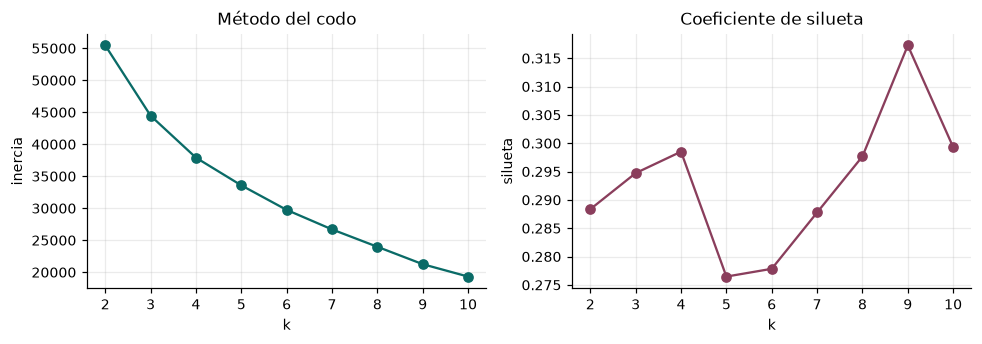

  k= 2   silueta 0.288
  k= 3   silueta 0.295
  k= 4   silueta 0.299
  k= 5   silueta 0.276
  k= 6   silueta 0.278
  k= 7   silueta 0.288
  k= 8   silueta 0.298
  k= 9   silueta 0.317
  k=10   silueta 0.299

Mejor silueta en k = 9


In [6]:
ks = list(range(2, 11))
inercias, siluetas = [], []
muestra = np.random.default_rng(SEMILLA).choice(len(X), min(3000, len(X)), replace=False)

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X)
    inercias.append(km_k.inertia_)
    siluetas.append(silhouette_score(X[muestra], km_k.labels_[muestra]))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(ks, inercias, "o-", color="#0A6B67")
a1.set_xlabel("k"); a1.set_ylabel("inercia"); a1.set_title("Método del codo")
a2.plot(ks, siluetas, "o-", color="#8A3E5C")
a2.set_xlabel("k"); a2.set_ylabel("silueta"); a2.set_title("Coeficiente de silueta")
plt.tight_layout(); plt.show()

for k, s in zip(ks, siluetas):
    print(f"  k={k:>2}   silueta {s:.3f}")
print(f"\nMejor silueta en k = {ks[int(np.argmax(siluetas))]}")

## Procedimiento 4 — Perfil de los grupos

Fijamos **k = 5**, un número manejable para interpretar, y describimos qué tipo de propiedad es cada
grupo. El precio aparece aquí solo como columna descriptiva: no participó en formar los grupos.

In [7]:
K_FIJO = 5
km = KMeans(n_clusters=K_FIJO, n_init=20, random_state=SEMILLA).fit(X)
seg["cluster"] = km.labels_

perfil = seg.groupby("cluster").agg(
    n=("precio_uf", "size"),
    m2=("m2_util", "median"),
    dorm=("dormitorios", "median"),
    banos=("banos", "median"),
    estac=("estacionamientos", "median"),
    antig=("antiguedad", "median"),
    gc_miles=("gastos_comunes_clp", "median"),
    precio_uf=("precio_uf", "median"),
).round(1)
perfil["gc_miles"] = (perfil["gc_miles"] / 1000).round(0)
perfil["uf_m2"] = (perfil["precio_uf"] / perfil["m2"]).round(1)
perfil["%"] = (100 * perfil["n"] / len(seg)).round(1)
print(perfil.to_string())

            n    m2  dorm  banos  estac  antig  gc_miles  precio_uf  uf_m2     %
cluster                                                                         
0        1491  76.0   3.0    2.0    1.0   10.0     140.0     5990.0   78.8  22.2
1        2338  37.0   1.0    1.0    0.0    6.0      70.0     2596.5   70.2  34.8
2         106  34.0   1.0    1.0  360.0    7.0       0.0     3097.0   91.1   1.6
3           2  57.0   2.5    2.0    0.0   15.0   82500.0     3084.8   54.1   0.0
4        2785  58.0   2.0    2.0    1.0    8.0      95.0     3416.0   58.9  41.4


## Procedimiento 5 — La prueba clave: ¿los grupos tienen precios distintos?

Aquí se decide si el dataset sirve. **η² (eta cuadrado)** es la proporción de la varianza del
log-precio que explica la simple pertenencia a un grupo formado sin mirar el precio.

Referencia de Cohen: 0,01 efecto pequeño · 0,06 mediano · **0,14 grande**.

Se usa el logaritmo porque la distribución del precio es asimétrica a la derecha y unas pocas
propiedades caras dominarían la varianza en escala original.

In [8]:
def eta_cuadrado(y, grupos):
    """Proporcion de la varianza de y que explica la pertenencia al grupo."""
    y = np.asarray(y, float)
    grupos = np.asarray(grupos)
    ss_total = ((y - y.mean()) ** 2).sum()
    ss_entre = sum(((y[grupos == g].mean() - y.mean()) ** 2) * (grupos == g).sum()
                   for g in np.unique(grupos))
    return ss_entre / ss_total


eta = eta_cuadrado(log_precio, km.labels_)
print(f"eta cuadrado = {eta:.3f}")
print(f"   los {K_FIJO} grupos, formados SIN ver el precio, explican el {100*eta:.1f}% de la")
print(f"   varianza del log-precio.\n")

# Control: cuanto daria agrupar al azar respetando los mismos tamanos de grupo.
rng = np.random.default_rng(SEMILLA)
azar = [eta_cuadrado(log_precio, rng.permutation(km.labels_)) for _ in range(200)]
print(f"Agrupando al azar: eta cuadrado = {np.mean(azar):.4f} "
      f"(maximo en 200 intentos: {max(azar):.4f})")
print(f"El valor observado es {eta/np.mean(azar):,.0f} veces mayor que el azar.\n")

print("Precio por grupo (UF):")
resumen = seg.groupby("cluster")["precio_uf"].describe(percentiles=[.25, .5, .75])
print(resumen[["count", "25%", "50%", "75%"]].round(0).to_string())
print(f"\nRazon entre el grupo mas caro y el mas barato (mediana): "
      f"{resumen['50%'].max()/resumen['50%'].min():.2f}x")

eta cuadrado = 0.574
   los 5 grupos, formados SIN ver el precio, explican el 57.4% de la
   varianza del log-precio.



Agrupando al azar: eta cuadrado = 0.0007 (maximo en 200 intentos: 0.0023)
El valor observado es 863 veces mayor que el azar.

Precio por grupo (UF):
          count     25%     50%     75%
cluster                                
0        1491.0  4999.0  5990.0  7100.0
1        2338.0  2150.0  2596.0  3135.0
2         106.0  2652.0  3097.0  3901.0
3           2.0  2803.0  3085.0  3366.0
4        2785.0  2938.0  3416.0  3900.0

Razon entre el grupo mas caro y el mas barato (mediana): 2.31x


In [9]:
# Traduccion del diagnostico a la metrica que usaremos despues: si predijeramos el
# precio con la sola mediana de cada grupo, cuanto nos equivocariamos.
pred_cluster = seg.groupby("cluster")["precio_uf"].transform("median").to_numpy()
mdape_cluster = np.median(100 * np.abs(pred_cluster - precio) / precio)
mdape_global = np.median(100 * np.abs(np.median(precio) - precio) / precio)

print(f"MdAPE prediciendo la mediana global      : {mdape_global:5.1f}%")
print(f"MdAPE prediciendo la mediana de su grupo : {mdape_cluster:5.1f}%")
print(f"Mejora por conocer solo el grupo         : {mdape_global - mdape_cluster:5.1f} puntos")
print("\nEs un piso, no una prediccion. Un modelo supervisado usa los atributos en")
print("detalle en vez de reducirlos a 5 categorias, y ademas esto esta medido en")
print("muestra, asi que es optimista. Sirve para saber que HAY senal, no cuanta.")

MdAPE prediciendo la mediana global      :  25.6%
MdAPE prediciendo la mediana de su grupo :  16.4%
Mejora por conocer solo el grupo         :   9.2 puntos

Es un piso, no una prediccion. Un modelo supervisado usa los atributos en
detalle en vez de reducirlos a 5 categorias, y ademas esto esta medido en
muestra, asi que es optimista. Sirve para saber que HAY senal, no cuanta.


## Procedimiento 6 — ¿El clustering redescubre la geografía?

Si al agrupar por atributos las comunas aparecen separadas por sí solas, la ubicación tiene señal
propia y no es una variable decorativa. Es un argumento a favor de incluir `lat` y `lon` en el modelo.

In [10]:
composicion = pd.crosstab(seg["cluster"], seg["comuna"], normalize="index").mul(100).round(1)
print("Composicion de cada grupo por comuna (%):")
print(composicion.to_string())

print(f"\nComuna dominante en cada grupo (%): {composicion.max(axis=1).round(0).to_dict()}")
print("Si los grupos fueran ciegos a la geografia, cada uno tendria ~25% de cada comuna.")

eta_comuna = eta_cuadrado(log_precio, seg["comuna"].to_numpy())
print(f"\nPara comparar:")
print(f"   eta cuadrado de la comuna sola sobre el log-precio : {eta_comuna:.3f}")
print(f"   eta cuadrado de los {K_FIJO} grupos de atributos          : {eta:.3f}")

Composicion de cada grupo por comuna (%):
comuna   la-florida  macul  nunoa  san-miguel
cluster                                      
0               3.6   10.7   78.5         7.2
1              28.0   18.3   20.7        33.0
2              39.6   13.2   39.6         7.5
3               0.0  100.0    0.0         0.0
4              37.8   21.4    6.6        34.2

Comuna dominante en cada grupo (%): {0: 78.0, 1: 33.0, 2: 40.0, 3: 100.0, 4: 38.0}
Si los grupos fueran ciegos a la geografia, cada uno tendria ~25% de cada comuna.

Para comparar:
   eta cuadrado de la comuna sola sobre el log-precio : 0.351
   eta cuadrado de los 5 grupos de atributos          : 0.574


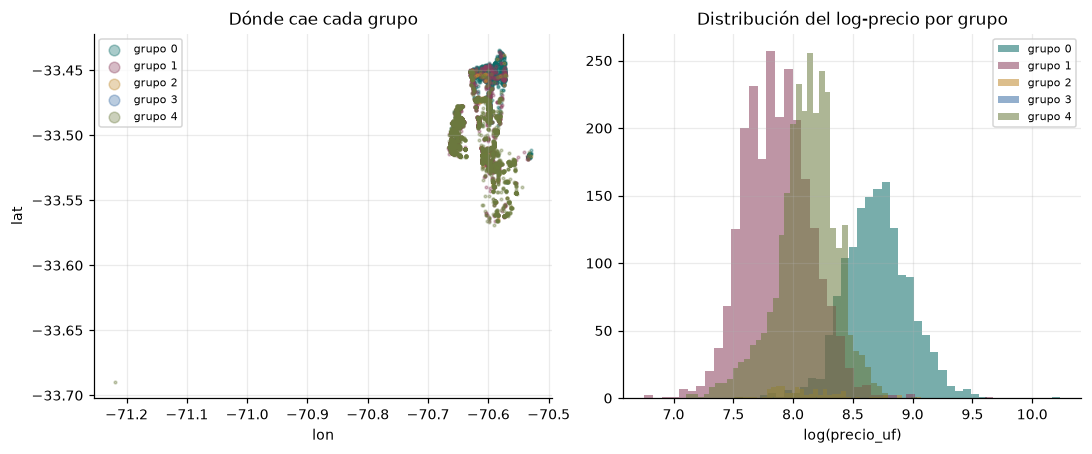

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))
colores = ["#0A6B67", "#8A3E5C", "#C08A2E", "#3B6EA5", "#6B7A3E"]

for c in range(K_FIJO):
    m = seg["cluster"] == c
    a1.scatter(seg.loc[m, "lon"], seg.loc[m, "lat"], s=3, alpha=0.35,
               color=colores[c], label=f"grupo {c}")
a1.set_title("Dónde cae cada grupo")
a1.set_xlabel("lon"); a1.set_ylabel("lat"); a1.legend(markerscale=4, fontsize=7)

for c in range(K_FIJO):
    a2.hist(np.log(seg.loc[seg["cluster"] == c, "precio_uf"]), bins=40, alpha=0.55,
            color=colores[c], label=f"grupo {c}")
a2.set_title("Distribución del log-precio por grupo")
a2.set_xlabel("log(precio_uf)"); a2.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Procedimiento 7 — ¿Hay zonas del espacio mal representadas?

Donde hay pocas observaciones el modelo tendrá que extrapolar, y ahí es donde fallará. Se mide con
el tamaño de cada grupo y con la distancia de cada propiedad a su centroide: las más lejanas son
casos raros, sea porque son atípicas de verdad o porque el dato está mal capturado.

In [12]:
distancias = np.linalg.norm(X - km.cluster_centers_[km.labels_], axis=1)
seg["dist_centroide"] = distancias
corte = np.percentile(distancias, 99)

tam = seg["cluster"].value_counts().sort_index()
print(f"Tamano de los grupos: {tam.to_dict()}")
print(f"El mas pequeno concentra el {100*tam.min()/len(seg):.1f}% de los avisos\n")

print(f"Propiedades mas alla del percentil 99 de distancia: {int((distancias > corte).sum())}")
print("\nLas 8 mas extremas (candidatas a error de captura):")
cols = ["comuna", "m2_util", "m2_total", "dormitorios", "banos",
        "estacionamientos", "bodegas", "antiguedad", "precio_uf"]
print(seg.nlargest(8, "dist_centroide")[cols].to_string(index=False))

Tamano de los grupos: {0: 1491, 1: 2338, 2: 106, 3: 2, 4: 2785}
El mas pequeno concentra el 0.0% de los avisos

Propiedades mas alla del percentil 99 de distancia: 68

Las 8 mas extremas (candidatas a error de captura):
    comuna  m2_util  m2_total  dormitorios  banos  estacionamientos  bodegas  antiguedad   precio_uf
la-florida     61.0      61.0          3.0    2.0               NaN      1.0     20111.0  2646.00000
la-florida     66.0      70.0         30.0    2.0               NaN      1.0         0.0  3400.00000
la-florida     24.0       NaN          2.0    1.0              70.0    350.0         NaN  1890.00000
     macul    305.0     524.0         10.0   10.0               5.0      1.0         1.0 10050.00000
     macul    306.0     523.0         10.0   10.0               5.0      1.0        13.0  9744.20483
     macul    305.0     305.0         10.0   10.0               5.0      0.0        13.0  9744.20483
san-miguel     52.0      52.0          2.0    2.0               1.0      

## Procedimiento 8 — Los errores de captura que el clustering destapó

Este resultado no estaba planificado. Al mirar el perfil del **Procedimiento 4** aparecen dos grupos
que no son segmentos de mercado sino **basura agrupada**:

- **Grupo 2** (106 avisos): mediana de **360 estacionamientos**. Ningún departamento tiene eso.
- **Grupo 3** (2 avisos): gastos comunes de **82.500 miles de pesos**, o sea 82,5 millones al mes.

k-means los separó del resto porque están tan lejos de todo lo demás que forman su propio grupo.
Es decir, el clustering funcionó aquí como **detector automático de anomalías**. Vale la pena
cuantificar el alcance del problema antes de construir el modelo.

In [13]:
problemas = {
    "estacionamientos > 10 (conteo del edificio)": seg["estacionamientos"] > 10,
    "bodegas > 10 (conteo del edificio)":          seg["bodegas"] > 10,
    "ano_construccion fuera de [1900, 2030]":      ~seg["ano_construccion"].between(1900, 2030)
                                                   & seg["ano_construccion"].notna(),
    "gastos_comunes > 3.000.000 CLP/mes":          seg["gastos_comunes_clp"] > 3_000_000,
    "dormitorios > 10":                            seg["dormitorios"] > 10,
    "m2_util > m2_total (inconsistente)":          seg["m2_util"] > seg["m2_total"],
}

print(f"{'problema':<46}{'filas':>7}{'% del segmento':>16}")
print("-" * 69)
afectadas = pd.Series(False, index=seg.index)
for nombre, mascara in problemas.items():
    mascara = mascara.fillna(False)
    afectadas |= mascara
    print(f"{nombre:<46}{int(mascara.sum()):>7}{100*mascara.mean():>15.2f}%")
print("-" * 69)
print(f"{'AL MENOS UNO':<46}{int(afectadas.sum()):>7}{100*afectadas.mean():>15.2f}%")

print("\nEjemplos de ano_construccion imposible:")
raros = seg.loc[~seg["ano_construccion"].between(1900, 2030) & seg["ano_construccion"].notna(),
                "ano_construccion"]
print(f"  valores distintos: {sorted(raros.unique())[:12]}")
print("  Los valores 0-30 son la ANTIGUEDAD escrita en el campo del ANO;")
print("  -18085 es un parseo roto. Ninguno es un ano de construccion.")

problema                                        filas  % del segmento
---------------------------------------------------------------------
estacionamientos > 10 (conteo del edificio)       117           1.74%
bodegas > 10 (conteo del edificio)                106           1.58%
ano_construccion fuera de [1900, 2030]             78           1.16%
gastos_comunes > 3.000.000 CLP/mes                  2           0.03%
dormitorios > 10                                    1           0.01%
m2_util > m2_total (inconsistente)                 95           1.41%
---------------------------------------------------------------------
AL MENOS UNO                                      296           4.40%

Ejemplos de ano_construccion imposible:
  valores distintos: [np.float64(-18085.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
  Los valores 0-30 son la A

## Conclusión

**Sí, el dataset sirve para entrenar un modelo de precio — y con señal fuerte.** Pero hay dos
matices que cambian cómo conviene construirlo, y un problema de calidad que hay que arreglar antes.

### 1. La señal existe, y es grande

**η² = 0,574.** Cinco grupos formados *sin ver el precio* explican el **57,4 %** de la varianza del
log-precio. La referencia de Cohen considera 0,14 un efecto grande, así que esto está cuatro veces
por encima. Agrupando al azar el mismo número de propiedades se obtiene 0,0007, o sea que lo
observado es **863 veces mayor que el azar**.

Traducido a la métrica que usaremos: predecir con la mediana global da 25,6 % de error; saber
únicamente a qué grupo pertenece una propiedad lo baja a 16,4 %. Y eso es un piso — un modelo
supervisado usa los atributos en detalle en vez de reducirlos a cinco categorías.

### 2. No hay segmentos discretos: hay un continuo

La silueta se queda entre **0,28 y 0,32** para todo *k* entre 2 y 10, sin un máximo claro. Bajo 0,5
la estructura es débil: no existen grupos naturales bien separados.

Esto podría parecer malo, pero **para lo que queremos hacer es una buena noticia**. Significa que los
atributos varían de forma continua y el precio los sigue de forma continua: exactamente el escenario
de una regresión. Si hubiera segmentos discretos y bien separados habría que plantearse un modelo por
segmento. Un η² alto con silueta baja es la firma de una **superficie de precios suave**.

### 3. Hopkins no sirvió aquí, y conviene decirlo

H = 0,995 sugeriría agrupamiento extremo, pero el control con las columnas barajadas dio **0,990**.
Es decir: el estadístico da prácticamente lo mismo con datos reales que con datos donde toda relación
entre variables fue destruida. Hopkins está detectando lo asimétrico de las distribuciones
marginales, no estructura real — es una limitación conocida del estadístico con datos sesgados.

**El control es lo que salvó la interpretación.** Sin él habríamos reportado «H = 0,995, estructura
clarísima», que habría sido falso.

### 4. La ubicación tiene señal propia

El grupo 0 es **78,5 % Ñuñoa** sin que la comuna entrara en la matriz: el clustering redescubrió la
geografía solo con `lat` y `lon`. Y la comuna por sí sola ya explica un **η² de 0,351** del
log-precio. Confirma que la ubicación debe entrar al modelo, y que las coordenadas crudas bastan
para capturarla.

### 5. Hay que limpiar antes de modelar: 4,4 % del segmento está corrupto

El clustering aisló la basura en grupos propios, funcionando como detector de anomalías:

| Problema | Filas | Qué es en realidad |
|---|---|---|
| `estacionamientos` > 10 (máx 540) | 117 | El conteo del **edificio entero**, no de la unidad |
| `bodegas` > 10 (máx 350) | 106 | Ídem |
| `m2_util` > `m2_total` | 95 | Inconsistencia del publicador |
| `ano_construccion` fuera de rango | 78 | Valores 0–30 son la **antigüedad** escrita en el campo del año; −18085 es un parseo roto |
| `gastos_comunes` > 3 millones/mes | 2 | Hasta 95 millones de pesos mensuales |
| `dormitorios` > 10 | 1 | 30 dormitorios en un departamento |
| **Al menos uno** | **296 (4,4 %)** | |

Ninguno rompe el dataset, pero todos meten ruido: un departamento de 34 m² con 360 estacionamientos
le enseña al modelo que los estacionamientos no valen nada.

### Qué hacer con esto

1. **Filtrar por rangos plausibles** cada variable antes de entrenar, anulando el campo en vez de
   descartar la fila cuando el resto del aviso es válido.
2. **`ano_construccion` necesita reparación**, no solo filtro: los valores 0–30 son antigüedad mal
   ubicada y se pueden recuperar como `2026 − valor`.
3. **No separar en modelos por cluster.** La silueta baja dice que no hay segmentos reales; conviene
   un modelo continuo sobre todo el segmento.
4. **Repetir este diagnóstico** en *venta-casa* y *arriendo* antes de asumir que se comportan igual.